In [7]:
import sys
import h5py

sys.path.insert(0,'/home/sven/repos/')
from pykdgrav3_utils import units
un = units.units(1, 600., verbose=True)

sys.path.append('/home/sven/repos/My_thesis/Modules')
from misc import plot_OD_gaussian

dMsolUnit = 1.000000e+00
dKpcUnit = 6.000000e+02
dGasConst =  1150890.1952769116
dErgPerGmUnit =  71.68174956254887
dGmPerCcUnit =  3.1333829769061664e-40
dSecUnit =  2.1867420491060357e+23
dKmPerSecUnit =  8.466507518602276e-05
dComovingGmPerCcUnit =  3.1333829769061664e-40


In [6]:
snapshot_dir = '/scratch/local/sven/hernquist_wake_dan/dm_sim.00001.0'

In [8]:
#file = '/home/dnurme/linux_env/Data/dm_sim.00001.0'

def load_snap_file(path, part_type='PartType1', is_print = False):

    snap_file = h5py.File(path, 'r')
    part_data = snap_file[part_type]

    if(is_print):
        print(f'Loading snapshot: {path.split("/")[-1]}')
        print(f'Selected species: {part_type}')
        print(f'Snap file keys: {snap_file.keys()}')
        print(f'Part type keys: {part_data.keys()}')

    return part_data

In [3]:
# ## Find LMC velocity when it is at 70 kpc distance. Also find its current position.

# orbitfile = '/home/dnurme/linux_env/Data/trajlmc.txt'
# orbit_full = pd.read_csv(orbitfile, delimiter = ' ')
# orbit = orbit_full.loc[np.where(orbit_full['time'] < 0.01)]
# d_orbit = np.sqrt(orbit['x']**2 + orbit['y']**2 + orbit['z']**2)
# loc70 = np.isclose(d_orbit, 70.0, 0.01)
# # 70 - d_orbit[loc70]
# v70 = orbit['Vx'][loc70].values[0], orbit['Vy'][loc70].values[0], orbit['Vz'][loc70].values[0]
# LMC_70 = np.array([orbit['x'][loc70].values[0], orbit['y'][loc70].values[0], orbit['z'][loc70].values[0]])

# LMC_today = np.isclose(orbit['time'], 0.0, 0.001)
# LMC_loc_today = np.array([orbit['x'][LMC_today].values[0], orbit['y'][LMC_today].values[0], orbit['z'][LMC_today].values[0]])


In [4]:
snap_stars = load_snap_file(file, part_type='PartType4', is_print=True)
star_coord = snap_stars['Coordinates'][:]*un.dKpcUnit



Loading snapshot: dm_sim.00001.0
Selected species: PartType4
Snap file keys: <KeysViewHDF5 ['Cosmology', 'Header', 'Parameters', 'PartType1', 'PartType4', 'Units']>
Part type keys: <KeysViewHDF5 ['Coordinates', 'GroupID', 'Masses', 'ParticleIDs', 'Potential', 'Softening', 'StellarFormationTime', 'Velocities']>


In [5]:
x = star_coord[:,0]
y = star_coord[:,1]
z = star_coord[:,2]
x = x[np.where((z > -60) & (z < 60))]
y = y[np.where((z > -60) & (z < 60))]
z = z[np.where((z > -60) & (z < 60))]

Smoothed half max overdensity: 0.2992
OD half max overdensity: 0.3594


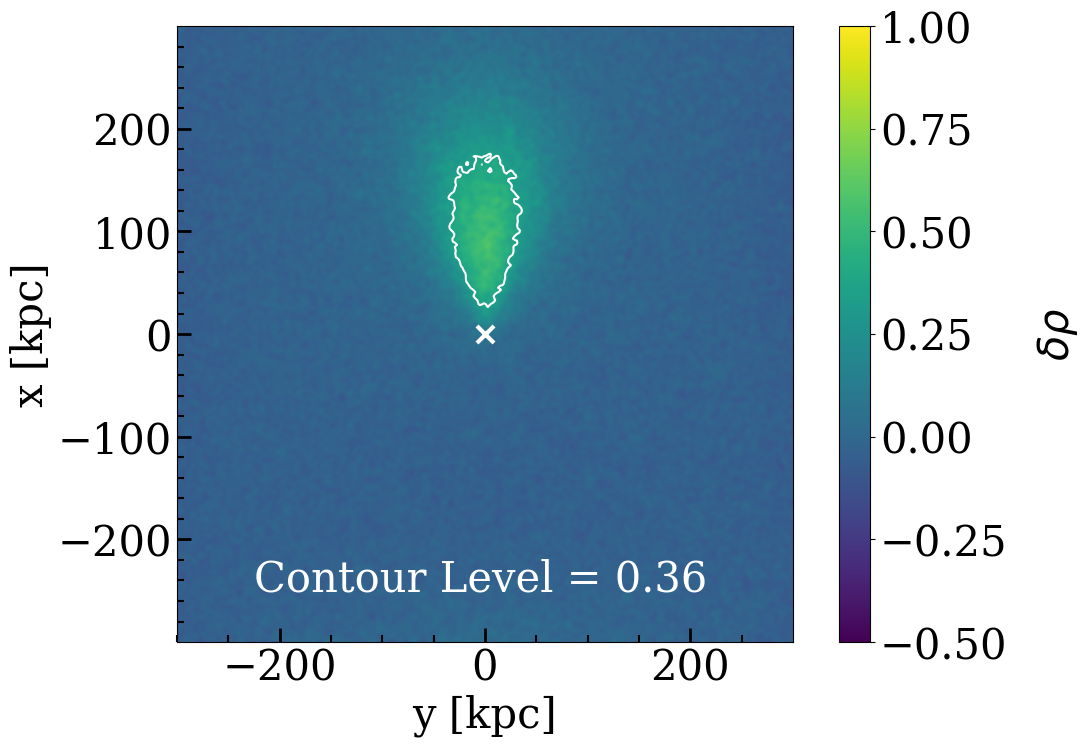

In [6]:
plot_OD_gaussian(y, x, (300, 300), 1, 'y [kpc]', 'x [kpc]')

In [7]:
print(len(star_coord[:,0]))

134217728
